# Atividade: Identificação NARX com Redes Neurais Artificiais (PyTorch)

Neste notebook, vamos adaptar o benchmark de Narendra para utilizar os dados reais do **Aeropêndulo**. O objetivo é treinar uma Rede Neural Artificial para modelar o sistema e avaliar o desempenho em predição One-Step-Ahead (OSA) e Free-Run (Simulação Livre).

In [241]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

# set random seed (reproducibility)
rseed = 42
np.random.seed(rseed)
torch.manual_seed(rseed)

# print precision
np.set_printoptions(precision=3)

## 1. Funções Auxiliares

Vamos definir a função `matReg` para montar as matrizes de regressão e a função `freeRun` para simulação livre. Utilizaremos as matrizes adaptadas que geram o regressor no formato adequado para o PyTorch.

In [242]:
def matReg(y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape

    # sanity check
    if N != Nu:
        print('Dimensions of u and y vector are not consistent')
        return (-1,-1)

    # create target vector
    target = y[p-1:N]

    # create regression matrix
    Phi = np.zeros((N-p+1, ny+nu))
    for i in range(ny):
        Phi[:, i] = y[p-i-2 : N-i-1]

    for i in range(nu):
        Phi[:, i+ny] = u[p-i-2 : N-i-1]

    return (target, Phi)


def freeRun(model, y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape

    yhat = np.zeros(N)
    yhat[:p-1] = y[:p-1] # include initial conditions

    for k in range(p, N+1):
        auxY = np.concatenate((yhat[(k-p):(k-1)], (0,)), axis=0)
        auxU = np.concatenate((u[(k-p):(k-1)], (0,)), axis=0)

        _, fr_input = matReg(auxY, auxU, ny, nu)
        
        # Converter regressor para tensor e fazer predição
        tensor_input = torch.tensor(fr_input, dtype=torch.float32)
        yhat[k-1] = model.predict(tensor_input).item()
        
    return yhat[-(N-p+1):]

## 2. Carregamento e Preparação dos Dados (Aeropêndulo)

Em vez de dados sintéticos, carregamos o caso de estudo com as respostas ao degrau.

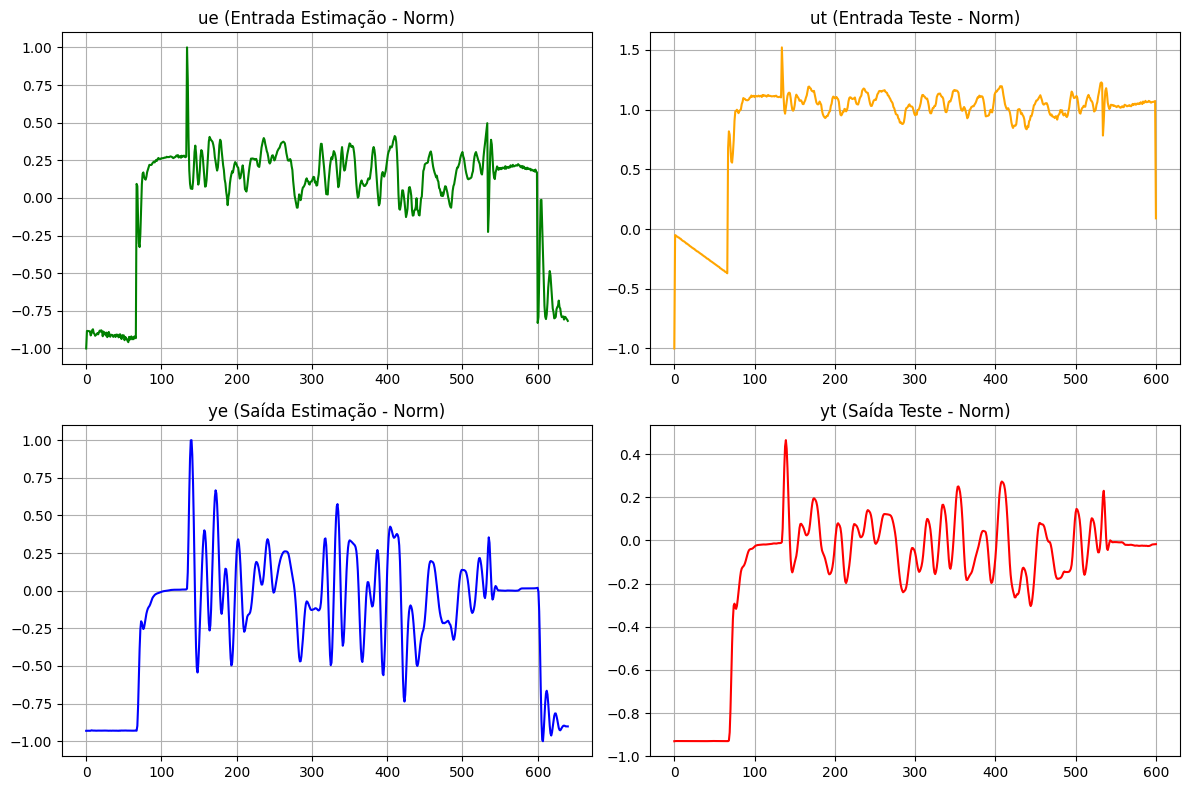

In [ ]:
def carregar_experimento(url, decimacao=1):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    
    # Suporte para cabeçalhos antigos (motor_percent) e novos (u_pct)
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
        
    y_raw = df_sub['angulo_deg'].values + 90.0
    u = u_raw - u_raw[0]
    y = y_raw  - y_raw[0]
    return u, y

# URL Antiga (pasta dados)
BASE = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/PYTHON/dados/"
)

# Nova URL (pasta experimentos)
BASE2 = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/experimentos/"
)

# ue, ye = carregar_experimento(BASE + "step_35_open.csv") # Estimação
# ut, yt = carregar_experimento(BASE + "step_39_open.csv") # Teste

ue, ye = carregar_experimento(BASE2 + "multi-sine-2_0731_17-38.csv") # Estimação
ut, yt = carregar_experimento(BASE2 + "multi-sine-3_0731_17-45.csv") # Teste 

ue, ye = carregar_experimento(BASE2 + "multi-sine-3_0731_17-45.csv", decimacao=15)
ut, yt = carregar_experimento(BASE2 + "multi-sine-2_0731_17-38.csv", decimacao=15)

# --- NORMALIZAÇÃO DOS DADOS ---
# Redes Neurais (especialmente com SELU) são altamente sensíveis à escala.
scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
ue_norm = scaler_u.fit_transform(ue.reshape(-1, 1)).flatten()
ye_norm = scaler_y.fit_transform(ye.reshape(-1, 1)).flatten()

ut_norm = scaler_u.transform(ut.reshape(-1, 1)).flatten()
yt_norm = scaler_y.transform(yt.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(ue_norm, color='green')
plt.title('ue (Entrada Estimação - Norm)')
plt.grid()
plt.subplot(222)
plt.plot(ut_norm, color='orange')
plt.title('ut (Entrada Teste - Norm)')
plt.grid()
plt.subplot(223)
plt.plot(ye_norm, color='blue')
plt.title('ye (Saída Estimação - Norm)')
plt.grid()
plt.subplot(224)
plt.plot(yt_norm, color='red')
plt.title('yt (Saída Teste - Norm)')
plt.grid()
plt.tight_layout()
plt.show()

## 3. Matrizes de Regressão e Tensores PyTorch

Construímos as matrizes usando as ordens do modelo. Escolhemos valores consistentes (como $ny=2, nu=2$, ou maiores dependendo do seu projeto).

In [244]:
ny = 4
nu = 4 # model orders

(Ye, Phie) = matReg(ye_norm, ue_norm, ny, nu)
(Yt, Phit) = matReg(yt_norm, ut_norm, ny, nu)

# Converter para tensores do PyTorch
Phie_t = torch.tensor(Phie, dtype=torch.float32)
Ye_t   = torch.tensor(Ye, dtype=torch.float32).view(-1, 1)

Phit_t = torch.tensor(Phit, dtype=torch.float32)
Yt_t   = torch.tensor(Yt, dtype=torch.float32).view(-1, 1)

ruido = torch.randn_like(Phie_t[:, :ny]) * 0.01 
Phie_t[:, :ny] += ruido

# DataLoader de treino
dataset = TensorDataset(Phie_t, Ye_t)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# DataLoader de teste
dataset_test = TensorDataset(Phit_t, Yt_t)
dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

## 4. Definição da Arquitetura da Rede Neural (PyTorch)

Usaremos uma rede Perceptron Multicamadas (MLP) com três camadas ocultas (função de ativação SELU).

In [245]:
class MyModel(nn.Module):
    def __init__(self, ny, nu, nneu):
        super(MyModel, self).__init__()
        self.hidden1 = nn.Linear(ny + nu, nneu)
        self.hidden2 = nn.Linear(nneu, int(nneu/2))
        self.output = nn.Linear(int(nneu/2), 1)

        # Inicialização Xavier (boa para tanh)
        nn.init.xavier_normal_(self.hidden1.weight)
        nn.init.zeros_(self.hidden1.bias)
        nn.init.xavier_normal_(self.hidden2.weight)
        nn.init.zeros_(self.hidden2.bias)
        nn.init.xavier_normal_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x):
        x = torch.tanh(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        x = self.output(x)
        return x

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)

# Instanciando o modelo, critério de erro e otimizador\n
model = MyModel(ny, nu, 80)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)


## 5. Treinamento do Modelo

Vamos realizar o loop de treinamento.

In [246]:
epochs = 2500  # Aumentamos o número de épocas para os dados reais convergirem melhor
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(dataloader)
    
    # Printar a cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}')

print("Treinamento finalizado!")

Epoch 1/2500, Loss: 0.0193
Epoch 5/2500, Loss: 0.0008
Epoch 10/2500, Loss: 0.0007
Epoch 15/2500, Loss: 0.0006
Epoch 20/2500, Loss: 0.0006
Epoch 25/2500, Loss: 0.0007
Epoch 30/2500, Loss: 0.0006
Epoch 35/2500, Loss: 0.0007
Epoch 40/2500, Loss: 0.0005
Epoch 45/2500, Loss: 0.0004
Epoch 50/2500, Loss: 0.0006
Epoch 55/2500, Loss: 0.0005
Epoch 60/2500, Loss: 0.0006
Epoch 65/2500, Loss: 0.0005
Epoch 70/2500, Loss: 0.0005
Epoch 75/2500, Loss: 0.0006
Epoch 80/2500, Loss: 0.0006
Epoch 85/2500, Loss: 0.0005
Epoch 90/2500, Loss: 0.0006
Epoch 95/2500, Loss: 0.0005
Epoch 100/2500, Loss: 0.0004
Epoch 105/2500, Loss: 0.0004
Epoch 110/2500, Loss: 0.0005
Epoch 115/2500, Loss: 0.0007
Epoch 120/2500, Loss: 0.0005
Epoch 125/2500, Loss: 0.0008
Epoch 130/2500, Loss: 0.0004
Epoch 135/2500, Loss: 0.0004
Epoch 140/2500, Loss: 0.0007
Epoch 145/2500, Loss: 0.0005
Epoch 150/2500, Loss: 0.0004
Epoch 155/2500, Loss: 0.0005
Epoch 160/2500, Loss: 0.0005
Epoch 165/2500, Loss: 0.0006
Epoch 170/2500, Loss: 0.0005
Epoch 1

## 6. One-Step-Ahead (OSA) Prediction

In [247]:
# One step ahead
y_train_pred1 = model.predict(Phie_t).numpy()
y_test_pred1  = model.predict(Phit_t).numpy()

# Desnormalizar para a escala original (graus)
y_train_pred1_real = scaler_y.inverse_transform(y_train_pred1.reshape(-1, 1)).flatten()
y_test_pred1_real  = scaler_y.inverse_transform(y_test_pred1.reshape(-1, 1)).flatten()
Ye_real = scaler_y.inverse_transform(Ye_t.numpy().reshape(-1, 1)).flatten()
Yt_real = scaler_y.inverse_transform(Yt_t.numpy().reshape(-1, 1)).flatten()

R2test1  = r2_score(Yt_real, y_test_pred1_real)
R2train1 = r2_score(Ye_real, y_train_pred1_real)

print('-------------- One step ahead (Escala Original) --------------')
print(f'R2 Train: {R2train1:.4f}')
print(f'R2 Test : {R2test1:.4f}')

-------------- One step ahead (Escala Original) --------------
R2 Train: 0.9979
R2 Test : 0.0484


## 7. Free-Run Simulation

Simulação recursiva onde a rede usa suas próprias predições passadas como entrada.

In [248]:
# Free Run apenas nos dados de teste
print("Executando Free-Run...")
y_test_pred0  = freeRun(model, yt_norm, ut_norm, ny, nu)

# Desnormalizar a predição do Free-Run para a escala original
y_test_pred0_real = scaler_y.inverse_transform(y_test_pred0.reshape(-1, 1)).flatten()

R2test0  = r2_score(Yt_real, y_test_pred0_real)

print('-------------- Free Run (Escala Original) --------------')
print(f'R2 Test (FR): {R2test0:.4f}')

Executando Free-Run...
-------------- Free Run (Escala Original) --------------
R2 Test (FR): -7.1464


## 8. Gráficos de Resultados

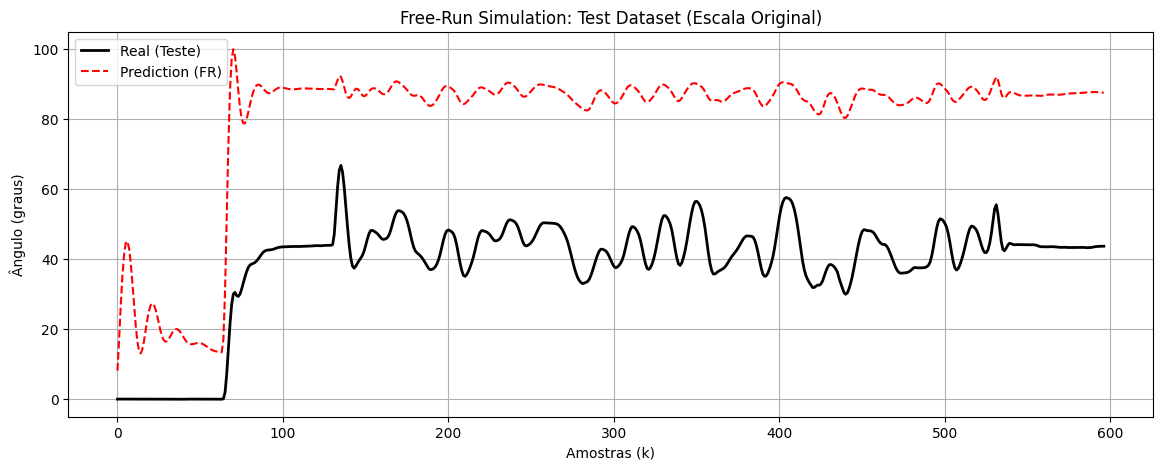

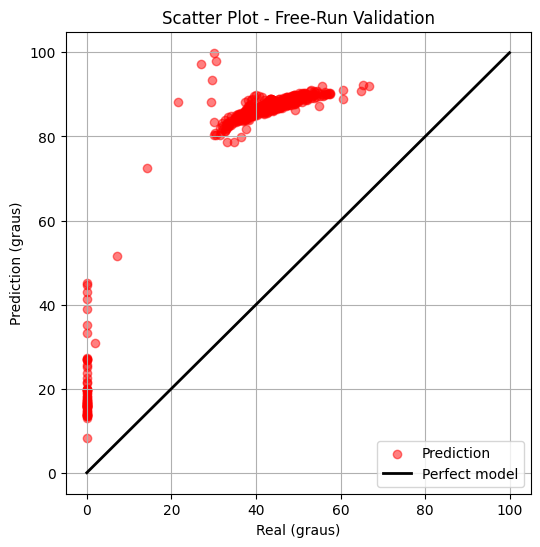

In [249]:
t_test = np.arange(len(Yt_real))

plt.figure(figsize=(14, 5))
plt.plot(t_test, Yt_real, 'k', lw=2, label='Real (Teste)')
plt.plot(t_test, y_test_pred0_real, 'r', ls='--', lw=1.5, label='Prediction (FR)')
plt.title('Free-Run Simulation: Test Dataset (Escala Original)')
plt.xlabel('Amostras (k)')
plt.ylabel('Ângulo (graus)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,6))
minY = min(Yt_real.min(), y_test_pred0_real.min())
maxY = max(Yt_real.max(), y_test_pred0_real.max())
plt.scatter(Yt_real, y_test_pred0_real, c='red', label='Prediction', alpha=0.5)
plt.plot([minY, maxY], [minY, maxY], color='black', linewidth=2, label='Perfect model')
plt.xlabel('Real (graus)')
plt.ylabel('Prediction (graus)')
plt.title('Scatter Plot - Free-Run Validation')
plt.grid()
plt.legend()
plt.show()